# End-to-end trainig

In [1]:
import torch

N_SRC = 10
BATCH_SIZE = 128
N_LCS = 10_000_000

DP1_ROOT = "../../data/dp1"
# DP1_ROOT = "/astro/store/epyc3/data3/hats/catalogs/dp1"
LSDB_WORKERS = 12
# DEVICE = "cpu"
# DEVICE = torch.device("cuda", 1)
DEVICE = "mps"

PLOT_MAGS = [18, 21, 25]

In [2]:
from uncle_val.learning.losses import (
    minus_ln_chi2_prob_loss,
    kl_divergence_whiten_loss,
    epps_pulley_whiten_loss,
)
from uncle_val.pipelines import run_dp1_constant_magerr

model_path = run_dp1_constant_magerr(
    dp1_root=DP1_ROOT,
    band="r",
    non_extended_only=True,
    n_workers=LSDB_WORKERS,
    n_src=N_SRC,
    n_lcs=N_LCS,
    loss_fn=epps_pulley_whiten_loss(lmbd=None, soft=None, kind="accum"),
    val_losses={
        "Total Soften KL": kl_divergence_whiten_loss(soft=20.0, kind="accum", lmbd=None),
        "Total Soften -ln(p_χ²)": minus_ln_chi2_prob_loss(soft=20.0, kind="accum", lmbd=None),
    },
    train_batch_size=BATCH_SIZE,
    val_batch_size=4098,
    snapshot_every=min(N_LCS // BATCH_SIZE // 50, 2048),
    start_tfboard=True,
    output_root="./runs",
    device=DEVICE,
)

Tensorboard Link: http://localhost:6006/
Dask Dashboard Link: http://127.0.0.1:8787/status


Training batch:   0%|          | 0/78125 [00:00<?, ?it/s]

2026-02-17 11:31:11,373 - tornado.application - ERROR - Uncaught exception GET /status/ws (127.0.0.1)
HTTPServerRequest(protocol='http', host='127.0.0.1:8787', method='GET', uri='/status/ws', version='HTTP/1.1', remote_ip='127.0.0.1')
Traceback (most recent call last):
  File "/Users/hombit/.virtualenvs/uncle-val/lib/python3.13/site-packages/tornado/websocket.py", line 965, in _accept_connection
    open_result = handler.open(*handler.open_args, **handler.open_kwargs)
  File "/Users/hombit/.virtualenvs/uncle-val/lib/python3.13/site-packages/tornado/web.py", line 3375, in wrapper
    return method(self, *args, **kwargs)
  File "/Users/hombit/.virtualenvs/uncle-val/lib/python3.13/site-packages/bokeh/server/views/ws.py", line 149, in open
    raise ProtocolError("Token is expired. Configure the app with a larger value for --session-token-expiration if necessary")
bokeh.protocol.exceptions.ProtocolError: Token is expired. Configure the app with a larger value for --session-token-expiration

In [10]:
# model_path = "/Users/hombit/projects/lincc-frameworks/uncle-val/docs/pre_executed/runs/2026-02-17_10-46/constant_magerr.pt"

print(model_path)
model = torch.load(model_path, weights_only=False)

for name, param in model.named_parameters():
    print(name, param)

/Users/hombit/projects/lincc-frameworks/uncle-val/docs/pre_executed/runs/2026-02-17_10-46/constant_magerr.pt
addition_centi_mag_err Parameter containing:
tensor([1.9615], device='mps:0', requires_grad=True)


In [17]:
from uncle_val.learning.models import ConstantMagErrModel

model_path = "/tmp/model.pt"
new_model = ConstantMagErrModel(input_names=["x", "err"])
new_model.addition_centi_mag_err = torch.nn.Parameter(torch.tensor(1.0))
torch.save(new_model, model_path)

### Train metrics

Dask Dashboard Link: http://127.0.0.1:8787/status


/Users/hombit/projects/lincc-frameworks/uncle-val/src/uncle_val/whitening.py:75: NumbaPerformanceWarning: '@' is faster on contiguous arrays, called on (Array(float64, 2, 'A', False, aligned=True), Array(float64, 2, 'C', False, aligned=True))
  transform_operator = whitening_operator(sigma, np=np)
/Users/hombit/projects/lincc-frameworks/uncle-val/src/uncle_val/whitening.py:75: NumbaPerformanceWarning: '@' is faster on contiguous arrays, called on (Array(float64, 2, 'A', False, aligned=True), Array(float64, 2, 'C', False, aligned=True))
  transform_operator = whitening_operator(sigma, np=np)
/Users/hombit/projects/lincc-frameworks/uncle-val/src/uncle_val/whitening.py:75: NumbaPerformanceWarning: '@' is faster on contiguous arrays, called on (Array(float64, 2, 'A', False, aligned=True), Array(float64, 2, 'C', False, aligned=True))
  transform_operator = whitening_operator(sigma, np=np)
/Users/hombit/projects/lincc-frameworks/uncle-val/src/uncle_val/whitening.py:75: NumbaPerformanceWarnin

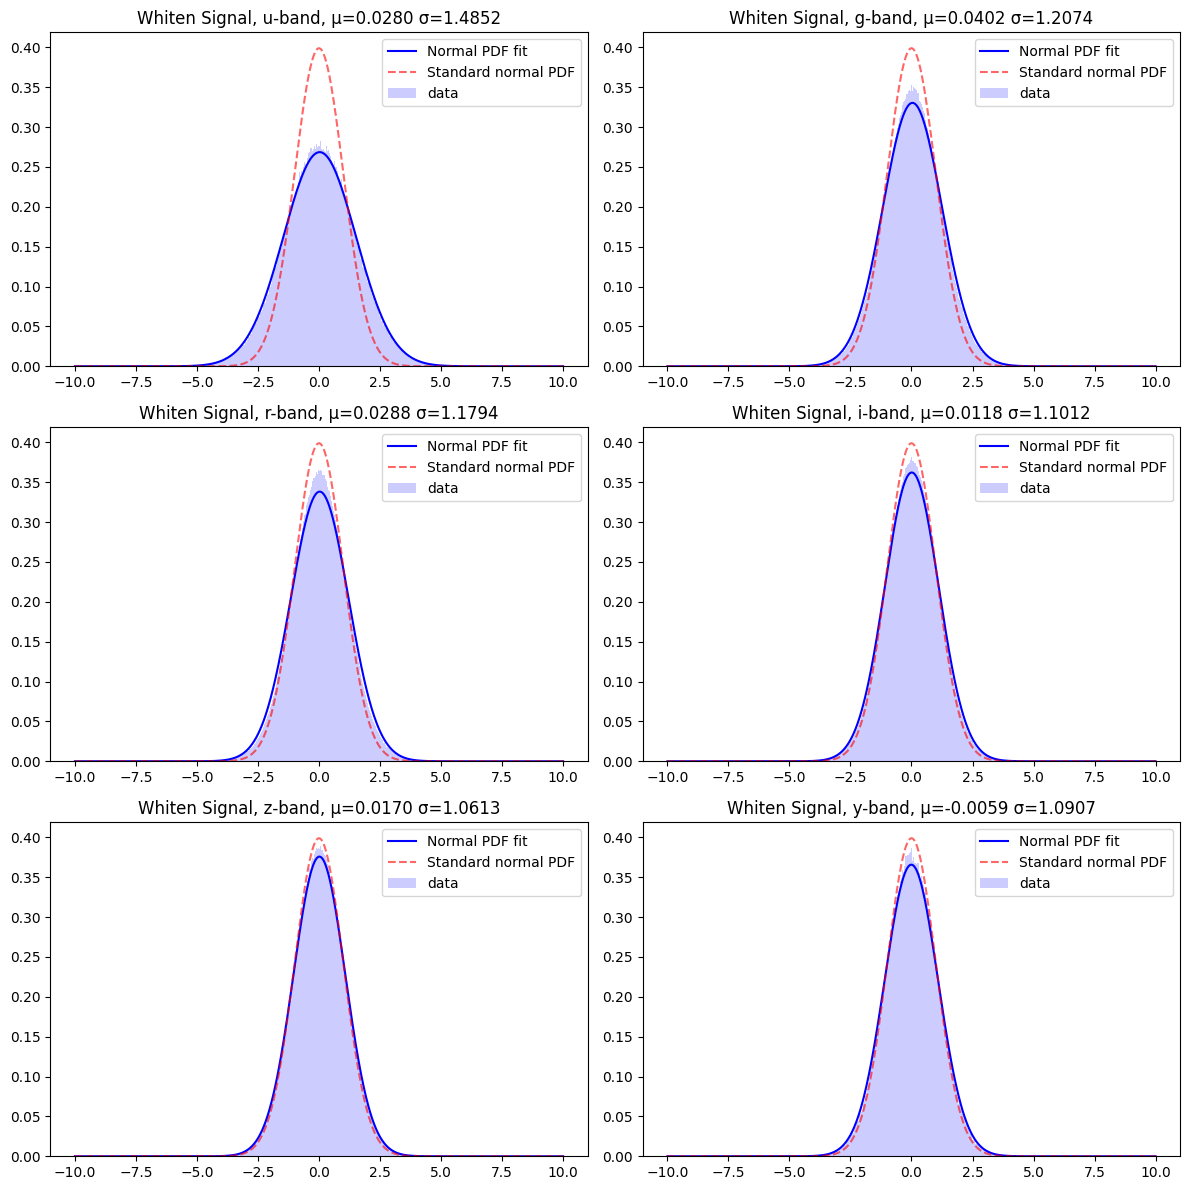

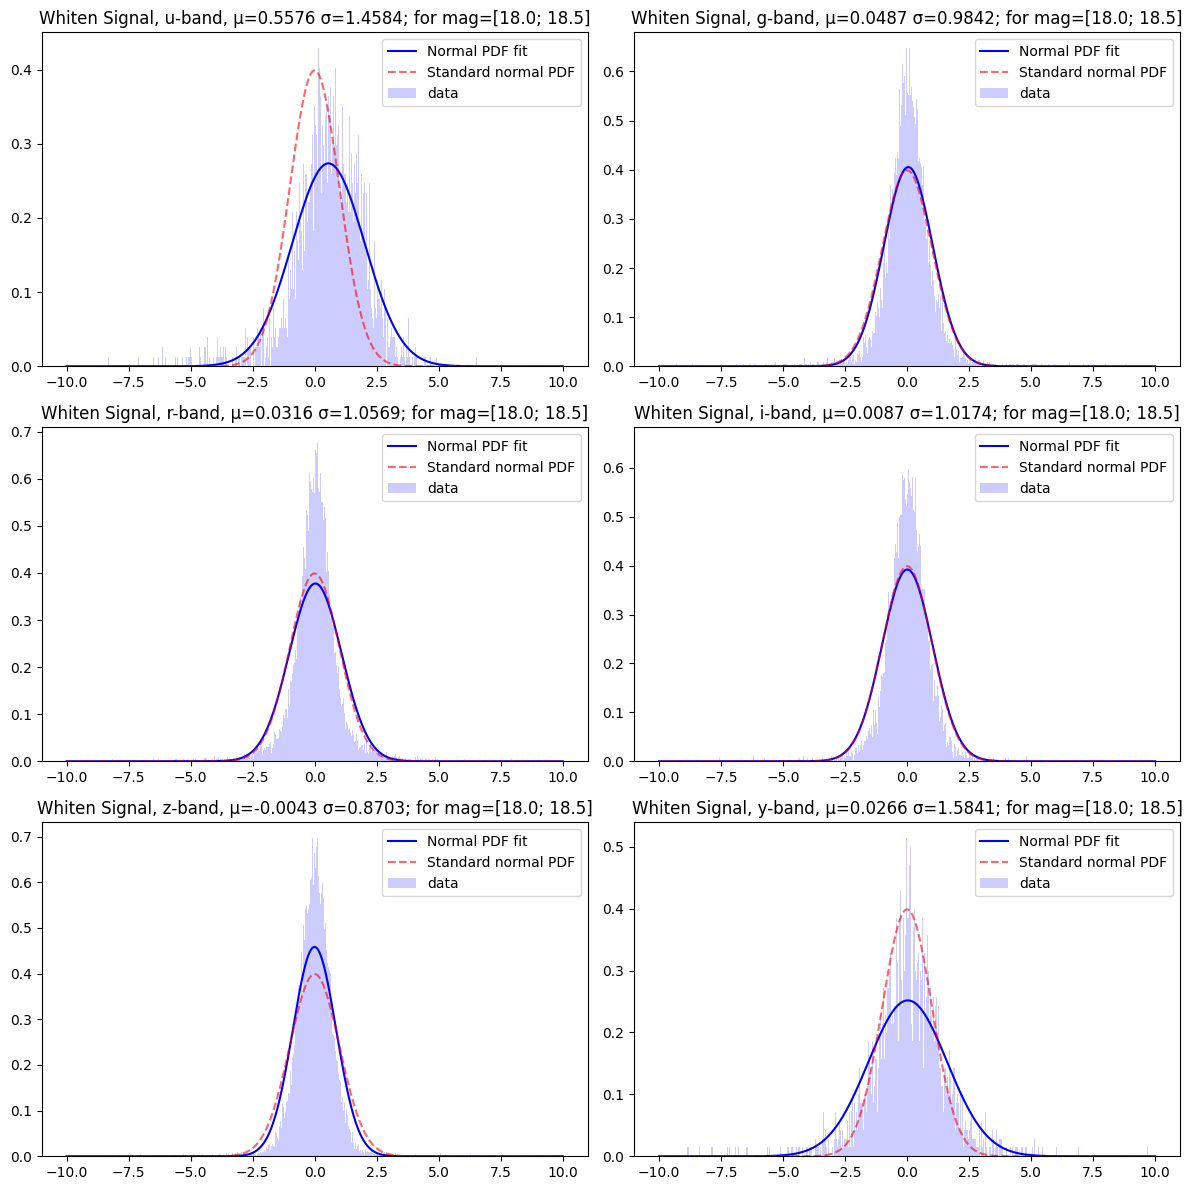

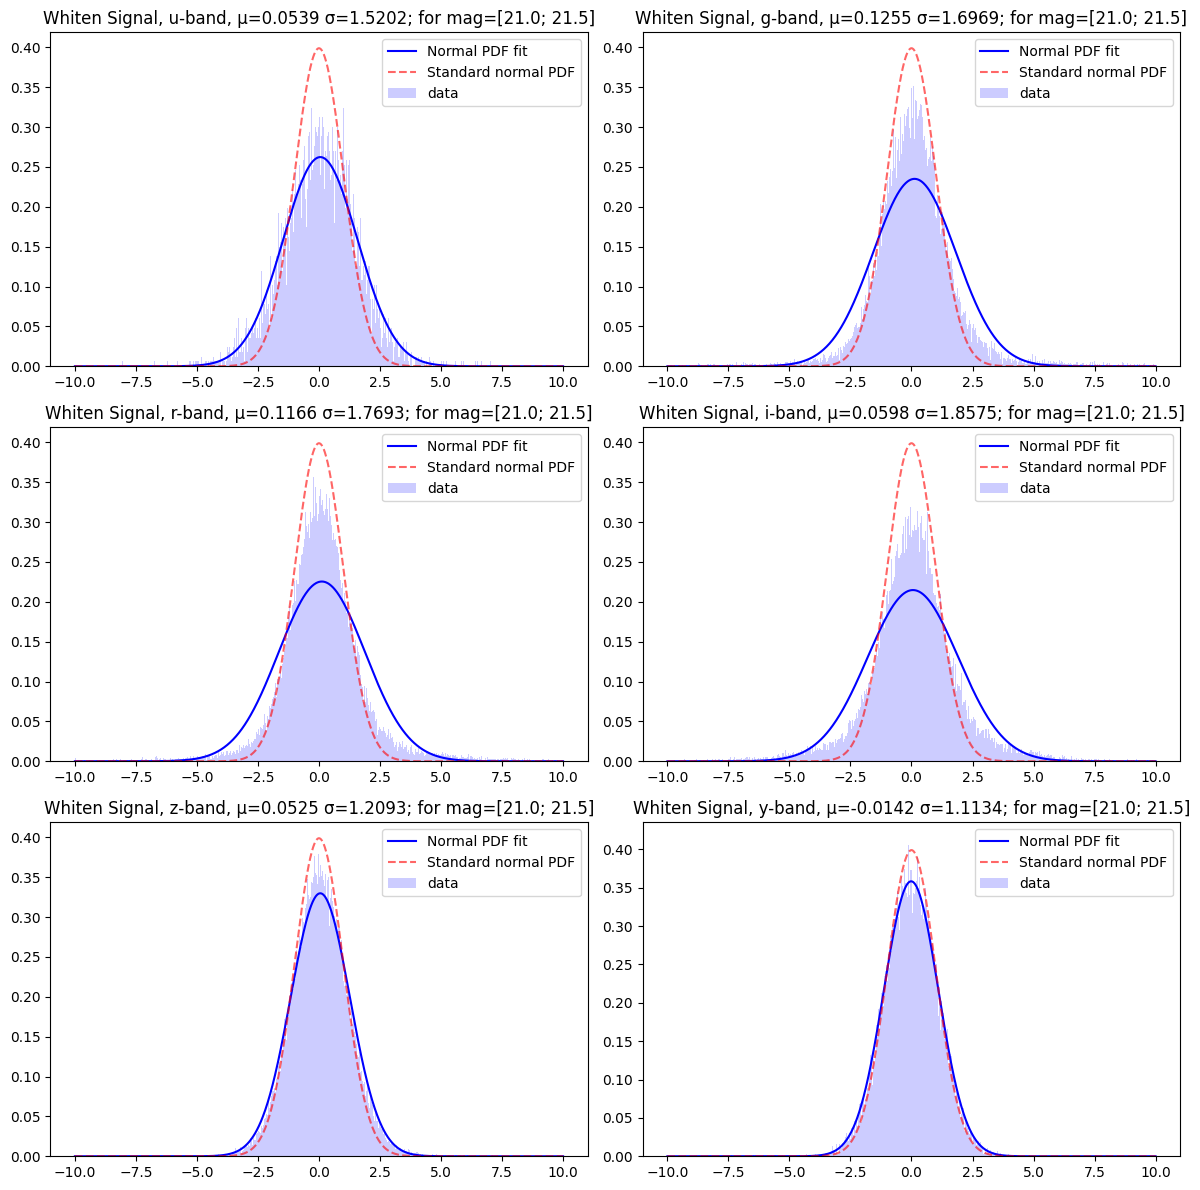

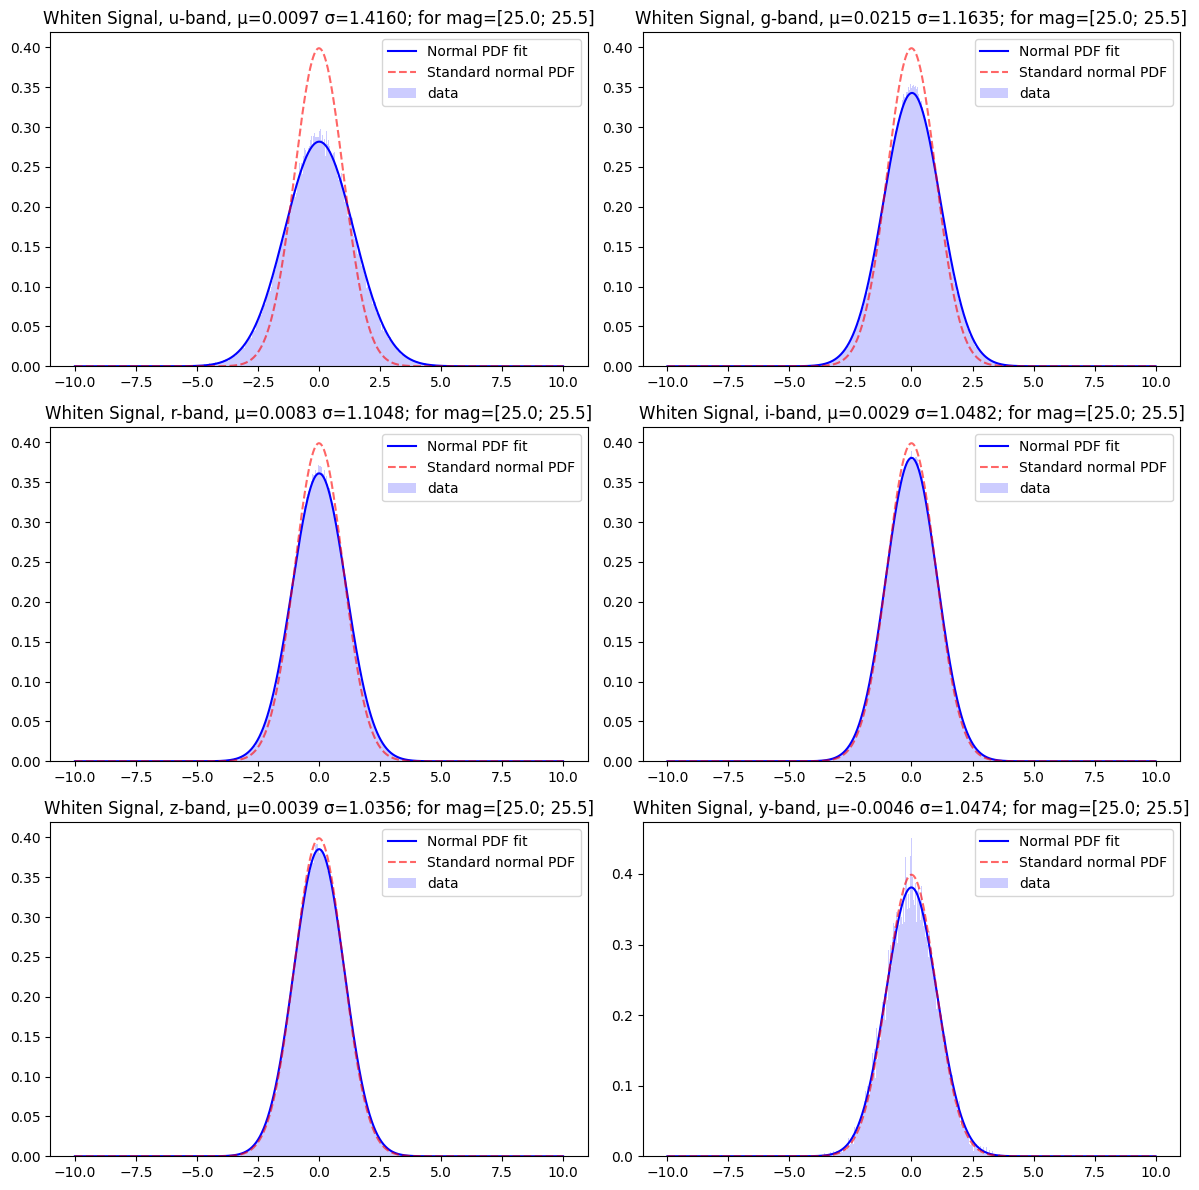

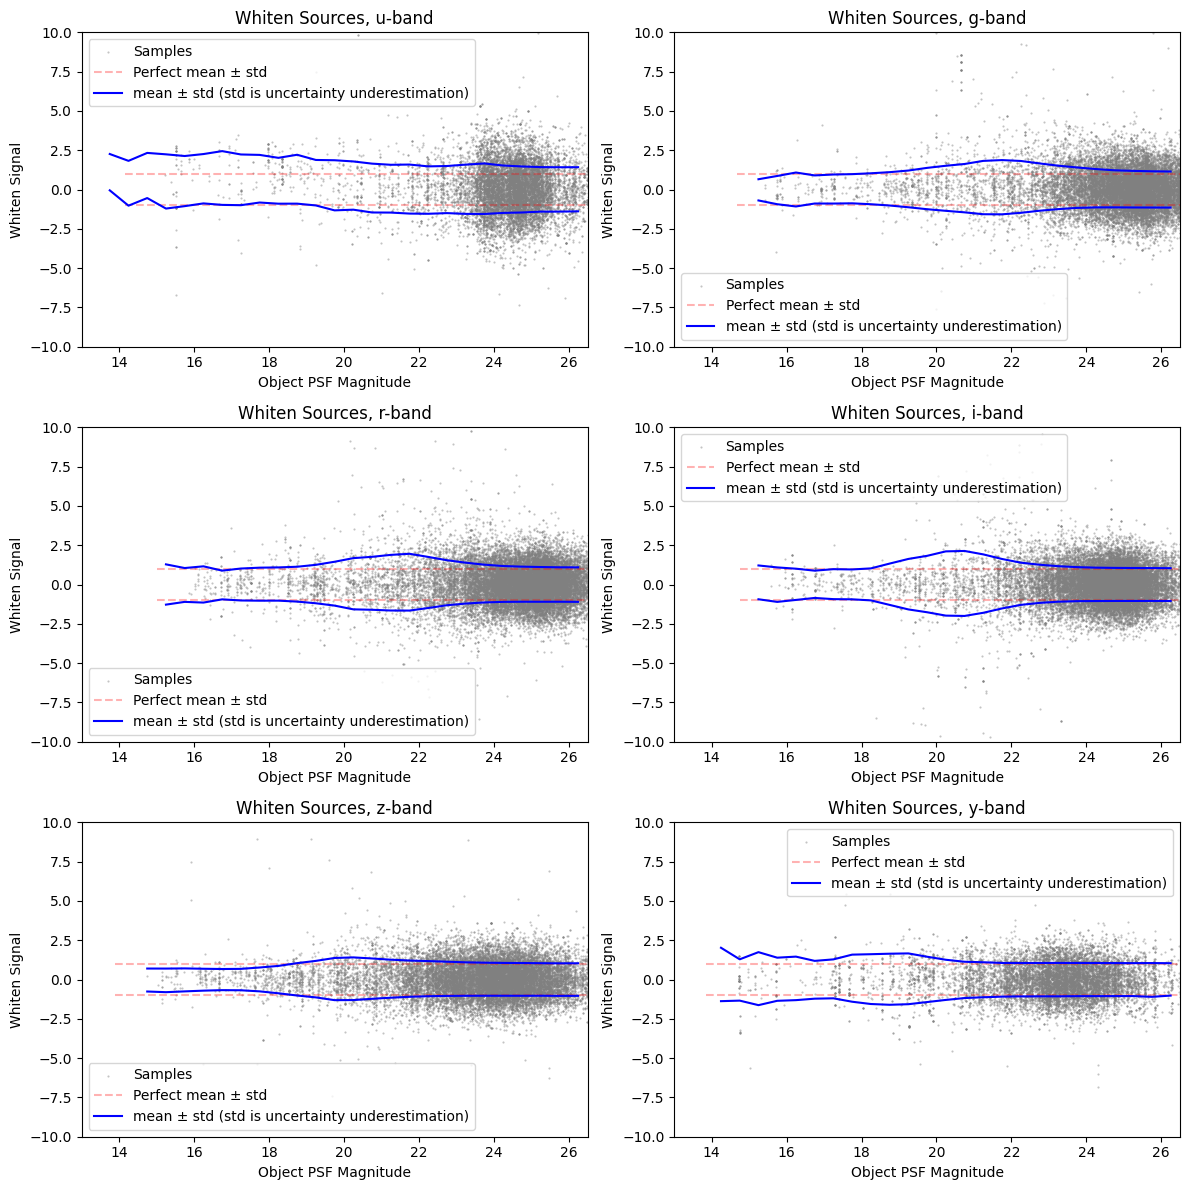

In [18]:
from uncle_val.pipelines import make_plots
from uncle_val.pipelines.splits import TRAIN_SPLIT

make_plots(
    dp1_root=DP1_ROOT,
    hash_range=TRAIN_SPLIT,
    min_n_src=N_SRC,
    non_extended_only=False,
    n_workers=LSDB_WORKERS,
    model_path=model_path,
    model_columns=["lc.x", "lc.err"],
    device=DEVICE,
    n_samples=5,
    object_mags=[18, 21, 25],
)

### Validation metrics

In [ ]:
from uncle_val.pipelines import make_plots
from uncle_val.pipelines.splits import VALIDATION_SPLIT

make_plots(
    dp1_root=DP1_ROOT,
    hash_range=VALIDATION_SPLIT,
    min_n_src=N_SRC,
    non_extended_only=False,
    n_workers=LSDB_WORKERS,
    model_path=model_path,
    model_columns=model_columns,
    # model_path="runs/2025-10-10_20-39/mlp.pt",
    # model_columns=['lc.x', 'lc.err', 'extendedness', 'is_u_band', 'is_g_band', 'is_r_band', 'is_i_band', 'is_z_band', 'is_y_band'],
    device=DEVICE,
    n_samples=5,
    object_mags=[18, 21, 25],
)

### Test metrics

In [ ]:
from uncle_val.pipelines import make_plots
from uncle_val.pipelines.splits import TEST_SPLIT

make_plots(
    dp1_root=DP1_ROOT,
    hash_range=TEST_SPLIT,
    min_n_src=N_SRC,
    non_extended_only=False,
    n_workers=LSDB_WORKERS,
    model_path=model_path,
    model_columns=model_columns,
    # model_path="./runs/2025-11-21_16-56/mlp.pt",
    # model_columns=['lc.x', 'lc.err', 'extendedness', 'lc.skyBg', 'lc.seeing', 'lc.expTime', 'is_u_band', 'is_g_band', 'is_r_band', 'is_i_band', 'is_z_band', 'is_y_band'],
    device=DEVICE,
    n_samples=5,
    object_mags=[18, 21, 25],
)